In [1]:
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import umap
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
INPUT = "/home/ensai/Cours/PFE/Topic-modeling-with-NLP/data/makeorg_biodiversite.xlsx"
df = pd.read_excel(INPUT)
texts = df['Proposition'].tolist()

In [3]:
# Option 1: BGE-M3 (recommandé pour français + multilangue)
#model = SentenceTransformer('BAAI/bge-m3')

# Option 2: all-MiniLM-L6-v2 (plus léger et rapide)
model = SentenceTransformer('all-MiniLM-L6-v2')

# Option 3: E5-Base (enterprise quality)
# model = SentenceTransformer('intfloat/e5-base')

embeddings = model.encode(texts, show_progress_bar=True)

print(f"Embeddings générés: shape {embeddings.shape}")
print(f"Exemple d'embedding (premiers 10 dims): {embeddings[0][:10]}")

Batches:   0%|          | 0/174 [00:00<?, ?it/s]

Embeddings générés: shape (5554, 384)
Exemple d'embedding (premiers 10 dims): [-0.01478562  0.03312883  0.00730395  0.01642478  0.00745207  0.00641455
  0.00030435  0.05804683  0.00947456  0.01948826]


In [ ]:
# ============================================================
# 4. TROUVER LE MEILLEUR K-MEANS (K entre 5 et 25)
# ============================================================

print("\nCherche le meilleur nombre de clusters...")
silhouette_scores = []
kmeans_models = []

for k in range(5, 25):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(embeddings)
    score = silhouette_score(embeddings, clusters)
    silhouette_scores.append(score)
    kmeans_models.append(kmeans)
    print(f"  K={k}: silhouette_score = {score:.4f}")

# Trouver le meilleur K
best_k_idx = np.argmax(silhouette_scores)
best_k = best_k_idx + 5  # Car on commence à K=5
best_silhouette = silhouette_scores[best_k_idx]
best_kmeans = kmeans_models[best_k_idx]

print(f"\n Meilleur K: {best_k} avec silhouette_score = {best_silhouette:.4f}")




Cherche le meilleur nombre de clusters...
  K=5: silhouette_score = 0.0296
  K=6: silhouette_score = 0.0280
  K=7: silhouette_score = 0.0309
  K=8: silhouette_score = 0.0291
  K=9: silhouette_score = 0.0297
  K=10: silhouette_score = 0.0260
  K=11: silhouette_score = 0.0259
  K=12: silhouette_score = 0.0265
  K=13: silhouette_score = 0.0268
  K=14: silhouette_score = 0.0277
  K=15: silhouette_score = 0.0265
  K=16: silhouette_score = 0.0288
  K=17: silhouette_score = 0.0285
  K=18: silhouette_score = 0.0288
  K=19: silhouette_score = 0.0298
  K=20: silhouette_score = 0.0303
  K=21: silhouette_score = 0.0267
  K=22: silhouette_score = 0.0268
  K=23: silhouette_score = 0.0327
  K=24: silhouette_score = 0.0273

 Meilleur K: 23 avec silhouette_score = 0.0327


In [5]:
# ============================================================
# 5. CLUSTERING FINAL AVEC LE MEILLEUR K
# ============================================================

final_clusters = best_kmeans.fit_predict(embeddings)
df['cluster'] = final_clusters

print(f"\nClustering final effectué")
print(f"Distribution des clusters:")
print(df['cluster'].value_counts().sort_index())


Clustering final effectué
Distribution des clusters:
cluster
0     102
1     326
2     229
3     167
4     493
5     276
6     432
7     265
8     506
9     228
10    183
11    175
12    132
13    142
14    216
15    197
16    258
17    237
18    150
19    220
20    277
21    289
22     54
Name: count, dtype: int64



Projection en 2D avec UMAP...


/home/ensai/Cours/PFE/Topic-modeling-with-NLP/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP projection effectuée
Graphique sauvegardé: clustering_biodiversite.png


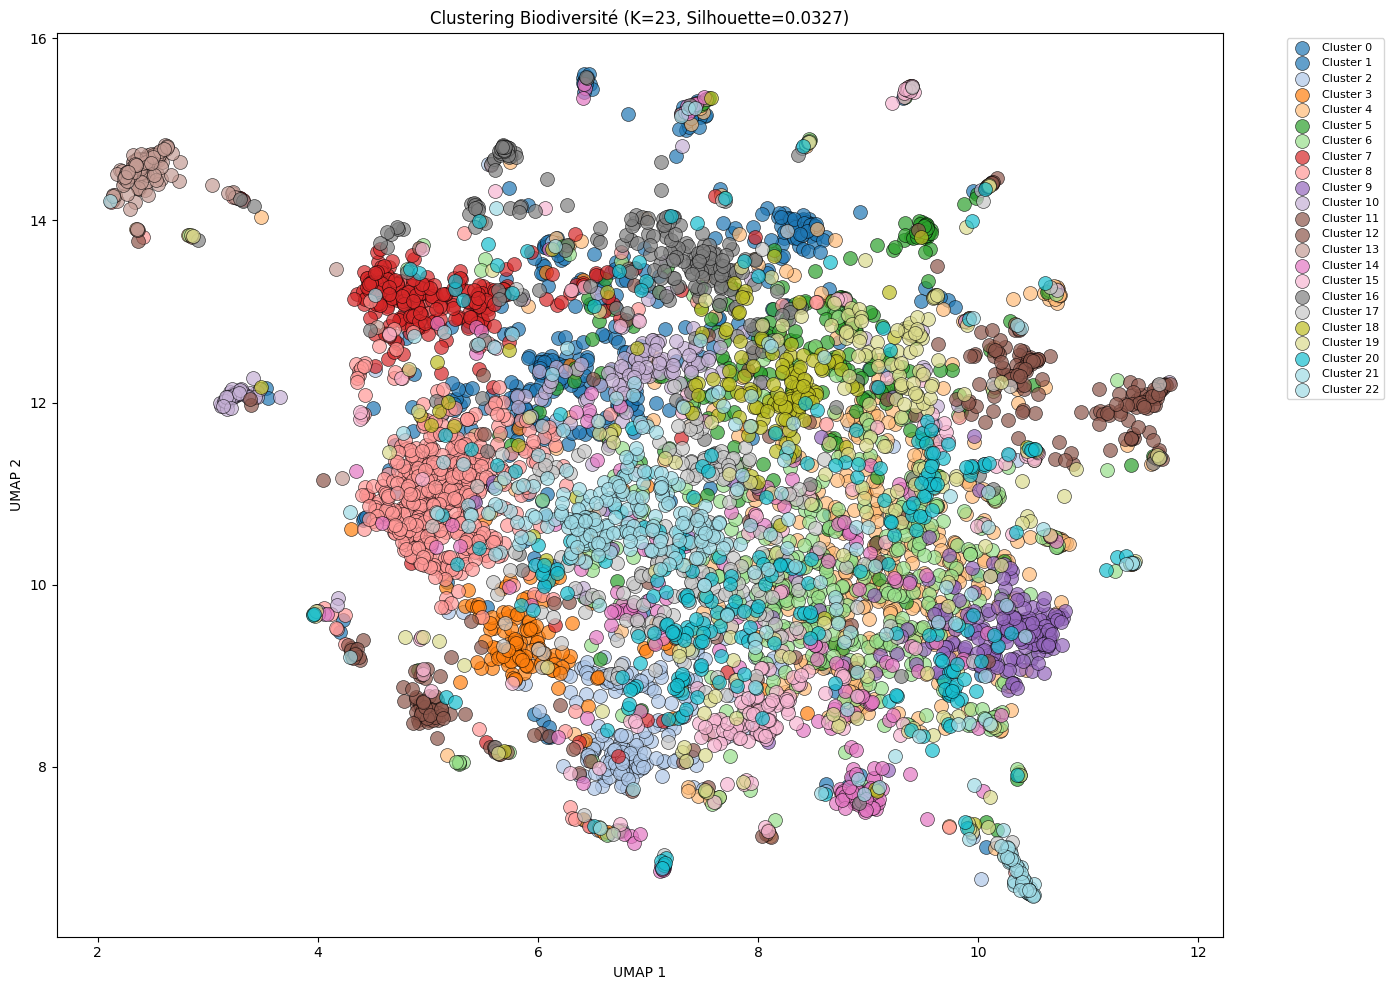

In [6]:
# ============================================================
# 6. PROJECTION 2D AVEC UMAP
# ============================================================

print("\nProjection en 2D avec UMAP...")
reducer = umap.UMAP(n_components=2, random_state=42, min_dist=0.1)
embeddings_2d = reducer.fit_transform(embeddings)

print(f"UMAP projection effectuée")

# ============================================================
# 7. VISUALISATION DES CLUSTERS
# ============================================================

plt.figure(figsize=(14, 10))
colors = plt.cm.tab20(np.linspace(0, 1, best_k))

for cluster_id in range(best_k):
    mask = final_clusters == cluster_id
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        c=[colors[cluster_id]],
        label=f'Cluster {cluster_id}',
        s=100,
        alpha=0.7,
        edgecolors='black',
        linewidth=0.5
    )

plt.xlabel(f'UMAP 1')
plt.ylabel(f'UMAP 2')
plt.title(f'Clustering Biodiversité (K={best_k}, Silhouette={best_silhouette:.4f})')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('clustering_biodiversite.png', dpi=300, bbox_inches='tight')
print("Graphique sauvegardé: clustering_biodiversite.png")
plt.show()

In [ ]:
# ============================================================
# 8. TOP 5 PROPOSITIONS PAR CLUSTER
# ============================================================

print("\n" + "="*70)
print("TOP 3 PROPOSITIONS PAR CLUSTER")
print("="*70)

for cluster_id in range(best_k):
    cluster_mask = df['cluster'] == cluster_id
    cluster_data = df[cluster_mask].copy()
    
    # Calculer la distance de chaque point au centroïde
    cluster_embeddings = embeddings[cluster_mask]
    centroid = best_kmeans.cluster_centers_[cluster_id]
    distances = np.linalg.norm(cluster_embeddings - centroid, axis=1)
    
    # Récupérer les 3 points les plus proches du centroïde
    top_3_indices = np.argsort(distances)[:5]
    top_3_propositions = cluster_data.iloc[top_3_indices]['Proposition'].values
    top_3_distances = distances[top_3_indices]
    
    print(f"\n CLUSTER {cluster_id} ({len(cluster_data)} propositions)")
    print("-" * 70)
    for i, (prop, dist) in enumerate(zip(top_3_propositions, top_3_distances), 1):
        print(f"{i}. {prop}")
        print(f"   Distance au centroïde: {dist:.4f}")
    print()



TOP 3 PROPOSITIONS PAR CLUSTER

 CLUSTER 0 (102 propositions)
----------------------------------------------------------------------
1. Il faut inciter les particuliers à laisser des jachères naturelles dans les jardins
   Distance au centroïde: 0.5033
2. Il faut inciter les gens qui ont des jardins à planter des fleurs,  et des arbres, les former via les médias .
   Distance au centroïde: 0.5263
3. Il faut sensibiliser les propriétaires de jardin aux dégâts faits par leurs tondeuses .
   Distance au centroïde: 0.5269
4. Il faut des jardins partagés dans toutes les villes
   Distance au centroïde: 0.5507
5. Il faut mettre en place des jardins partagés dans toutes les villes
   Distance au centroïde: 0.5624


 CLUSTER 1 (326 propositions)
----------------------------------------------------------------------
1. Il faut créer plus d&apos;habitats naturels protégés, réintroduire plus de prédateurs et y interdire la chasse.
   Distance au centroïde: 0.5379
2. Il faut s&apos;associer avec 

# Clusters from 'all-MiniLM-L6-v2' embeddings

## Top 3 propositions par cluster


### Cluster 0 : Jardins favorables à la biodiversité
- Inciter les particuliers à laisser des jachères naturelles dans les jardins  
- Encourager la plantation de fleurs et d’arbres dans les jardins  
- Sensibiliser aux dégâts causés par la tonte intensive 

### Cluster 1 : Restauration des habitats naturels et des écosystèmes
- Créer davantage d’habitats naturels protégés et y interdire la chasse  
- Planter des haies pour recréer des habitats pour le vivant  
- Restaurer les bandes riveraines avec une végétation dense  

### Cluster 2 : Fiscalité écologique et responsabilisation économique
- Taxer les entreprises sur leur consommation de ressources naturelles  
- Mettre en place une taxe biodiversité sur les produits destructeurs  
- Taxer plus fortement les importations nocives pour la santé et la nature 

### Cluster 3 : Gouvernance écologique et priorités politiques
- Faire appel à des experts écologues plutôt qu’à une écologie politisée  
- Cesser de privilégier les intérêts économiques sur l’écologie  
- Faire porter l’effort écologique sur les industries et les plus riches 

### Cluster 4 : Gestion écologique des espaces publics
- Ramasser les déchets avant la tonte des espaces verts  
- Protéger certaines espèces à des périodes clés (ex. brame du cerf)  
- Arrêter la tonte excessive des pelouses communales 

### Cluster 5 : Urbanisme, mobilité et végétalisation
- Interdire le stationnement des véhicules sur les trottoirs  
- Faciliter l’accès aux déchèteries pour éviter les dépôts sauvages  
- Imposer un pourcentage minimal d’arbres et de parcs en ville  

### Cluster 6 : Sobriété, consommation et arbitrages écologiques
- Réduire certaines pratiques sans compromettre la souveraineté alimentaire  
- Encourager la consigne pour les emballages  
- Éduquer à la prise de recul face à la surconsommation  

### Cluster 7 : Agriculture durable et agroécologie
- Promouvoir l’agroécologie respectueuse de la biodiversité  
- Rediriger les aides vers l’agriculture vertueuse  
- Soutenir l’agriculture biologique, la permaculture et l’agroforesterie  

### Cluster 8 : Sensibilisation et engagement citoyen
- Encourager et valoriser les actions favorables à la biodiversité  
- Sensibiliser le public au rôle vital de la biodiversité  
- Aider les citoyens à adopter des gestes favorables au vivant  


### Cluster 9 : Interdiction de la chasse
- Interdire la chasse  
- Interdire la chasse sur tout le territoire  
- Interdire la chasse en enclos  


### Cluster 10 : Protection des zones naturelles et humides
- Stopper l’extension des lotissements sur les espaces sauvages  
- Réserver certaines cultures aux zones adaptées en eau  
- Sanctuariser et restaurer les zones humides 

### Cluster 11 : Routes et transports durables
- Arrêter la construction de nouvelles routes  
- Interdire le fauchage systématique des bords de routes  
- Développer les transports en commun  

### Cluster 12 : Pollution, matériaux et alimentation
- Intégrer des critères biodiversité et pollution dans les marchés publics  
- Prévenir la pollution des sols et des eaux (ex. plomb de chasse)  
- Abandonner les matériaux dangereux et polluants  

### Cluster 13 : Fin des pesticides
- Interdire tous les pesticides chimiques nocifs  
- Protéger la flore en supprimant les pesticides  
- Mettre fin aux pesticides responsables de l’effondrement du vivant 

### Cluster 14 — Protection animale et espèces menacées
- Créer un ministère de la protection animale  
- Protéger fortement les espaces naturels les plus menacés  
- Soutenir la conservation des espèces menacées 

### Cluster 15 — Gestion des déchets et emballages
- Revenir à la consigne pour limiter les emballages plastiques  
- Faire porter le coût du recyclage sur les industriels  
- Améliorer le recyclage par les collectivités

### Cluster 16 — Arbres et végétalisation urbaine
- Planter des arbres fruitiers en ville  
- Éduquer à la connaissance des plantes  
- Planter des arbres dans l’espace urbain dès que possible  

### Cluster 17 — Actions locales et transition énergétique
- Installer des panneaux solaires sur les bâtiments publics  
- Créer des vergers communaux  
- Organiser des activités nature gratuites pour tous  


### Cluster 18 — Espaces verts en libre évolution
- Sanctuariser durablement les espaces verts publics  
- Former les agents à la gestion écologique des espaces naturels  
- Laisser certains espaces sans tonte ni intervention 

### Cluster 19 — Construction durable et eau
- Imposer la récupération des eaux de pluie dans les constructions  
- Construire sans artificialiser davantage les sols  
- Mettre fin à toute nouvelle artificialisation des terres vivantes 

### Cluster 20 — Régulation, chasse et responsabilité des entreprises
- Empêcher l’influence des entreprises sur les règles environnementales  
- Interdire l’élevage d’animaux destinés à la chasse  
- Intégrer le nettoyage des milieux naturels dans les travaux d’intérêt général

### Cluster 21 — Éducation à la nature et laisser-faire écologique
- Apprendre le respect de la nature dès la maternelle  
- Multiplier les classes vertes et sorties nature  
- Laisser la nature se réguler avant toute réintroduction  

### Cluster 22 — Gestion des chats errants
- Stériliser les chats pour protéger la petite faune  
- Mettre en place une campagne massive de stérilisation  
- Rendre la stérilisation obligatoire pour les chats ayant accès à l’extérieur

# Clusters from Word2Vec
## Cluster 0
**Réduction du plastique et des emballages**  
(Consigne, verre, suppression du suremballage)

## Cluster 1
**Transition agroécologique et agriculture biologique**  
(Agriculture durable, biodiversité, pratiques agricoles)

## Cluster 2
**Interdiction des pesticides et des importations non conformes**  
(Normes environnementales, produits chimiques)

## Cluster 3
**Réduction de l’élevage intensif et de la consommation de viande**

## Cluster 4
**Protection de la faune locale face aux animaux domestiques**  
(Chats, oiseaux, stérilisation, limitation des impacts)

## Cluster 5
**Lutte contre les déchets abandonnés et les décharges sauvages**

## Cluster 6
**Interdiction ou régulation stricte de la chasse et de la pêche destructrice**

## Cluster 7
**Gestion durable et protection de la ressource en eau**

## Cluster 8
**Protection et restauration des espaces naturels et zones protégées**

## Cluster 9
**Valorisation des fruits et légumes locaux, de saison et hors normes**

## Cluster 10
**Urbanisme durable et construction respectueuse de l’environnement**  
(Limitation de l’artificialisation, végétalisation, solaire)

## Cluster 11
**Développement des espaces verts et de la biodiversité en ville**

## Cluster 12
**Plantation et protection des arbres, haies et bocages**

## Cluster 13
**Éducation et sensibilisation des enfants à la nature et à la biodiversité**

## Cluster 14
**Protection des espèces animales sauvages et de la faune**

## Cluster 15
**Réduction des nuisances humaines pour la faune**  
(Éclairage nocturne, routes, infrastructures)

## Cluster 16
**Actions transversales pour la protection de la biodiversité**  
(Entreprises, citoyens, politiques publiques)

## Cluster 17
**Réduction de l’impact environnemental des transports et de l’énergie**

## Cluster 18
**Protection des forêts et fin des pratiques forestières destructrices**
